In [1]:
%pip install ipympl
%matplotlib widget

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal
from scipy.fft import rfftfreq, rfft

In [3]:
# Read WAV file and return data and properties
def read_mono(file_name):
    sample_rate, data = wavfile.read(file_name)
    
    # Check if the file is stereo or mono
    if len(data.shape) > 1:
        # It's stereo: average the left (channel 0) and right (channel 1) to make it mono
        mono_data = (data[:, 0].astype(float) + data[:, 1].astype(float)) / 2
    else:
        # It's already mono
        mono_data = data.astype(float)
    
    f = rfftfreq(len(mono_data), (1/sample_rate))
    return mono_data, f, sample_rate

In [4]:
# Helper function for graphing
def plot(x, y, title, xlabel, ylabel, xmax=25000):
    plt.figure(figsize=(10, 4))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.plot(x, y)
    
    if xmax != 25000:
        plt.xlim(0, xmax)

    plt.tight_layout()
    plt.show()

In [5]:
# Filtering function
# Uses butterworth IIR filter
# SOS (second-order sections) method breaks down filtration into small pieces to reduce noise
def adjust_frequencies_in_time(sample_rate, time_signal, min_freq=0, max_freq=0, filter='hpf', filter_order=1):
    # High pass filter attenuates frequencies below cutoff
    if filter == 'hpf':
        sos = signal.butter(N=filter_order, Wn=min_freq, btype='highpass', fs=sample_rate, output='sos')
        filtered_signal = signal.sosfiltfilt(sos, time_signal)
    # Low pass filter attenuates frequencies above cutoff
    elif filter == 'lpf':
        sos = signal.butter(N=filter_order, Wn=max_freq, btype='lowpass', fs=sample_rate, output='sos')
        filtered_signal = signal.sosfiltfilt(sos, time_signal)
    # Band pass filter attenuates frequencies outside of frequency band defined
    elif filter == 'bpf':
        sos = signal.butter(N=filter_order, Wn=[min_freq, max_freq], btype='bandpass', fs=sample_rate, output='sos')
        filtered_signal = signal.sosfiltfilt(sos, time_signal)
        
    return filtered_signal

In [ ]:
# Write finalized output file
# Normalize and scale channels before combining and writing to output WAV file
def write_file(reconstructed_left, reconstructed_right, sample_rate, output_filename):
    # Find the max amplitude per channel
    max_left = np.max(np.abs(reconstructed_left))
    max_right = np.max(np.abs(reconstructed_right))
    if max_left == 0:
        max_left = 1
    if max_right == 0:
       max_right = 1

    # Normalize both channels to +-1
    normalized_left = reconstructed_left / max_left
    normalized_right = reconstructed_right / max_right

    # Scale both channels to 16 bit (word)
    scaled_left = normalized_left * 32767.0
    # Scale right channel (bass) to not dominate over mids/highs in left channel
    scaled_right = (normalized_right * 32767.0) / 2

    # scaled_left represents the mids/highs that are outputted from the left channel device
    # scaled_right represents the lows that are outputted from right channel device
    reconstructed_real = np.stack((scaled_left, scaled_right), axis=1)
    audio_data_int16 = np.int16(np.clip(reconstructed_real, -32768, 32767.0))

    wavfile.write(output_filename, sample_rate, audio_data_int16)

    return audio_data_int16

In [7]:
#Helper function to graph FFT amplitudes
def transform(data, sample_rate):
    n = len(data)

    f_transform = rfft(data)
    amplitude = np.abs(f_transform) / n

    return amplitude


In [8]:
# Convert song to mono and place it in the left channel
#
# For proof of concept, using mono audio as an input
# and generating two channel output
# One channel for mids/highs (left channel)
# One channel for harmonics of lows (right channel)
data, f, sample_rate = read_mono("i_wanna_be_your_man.wav")
right_data = np.zeros_like(data)
combined = np.stack((data, right_data), axis=1)
audio_data = np.int16(np.clip(combined, -32768, 32767.0))

wavfile.write('i_wanna_be_your_man_single.wav', sample_rate, audio_data)

C:\Users\eranm\AppData\Local\Temp\ipykernel_34792\3277997189.py:3: WavFileWarning: Reached EOF prematurely; finished at 18641039 bytes, expected 4294967303 bytes from header.
  sample_rate, data = wavfile.read(file_name)


In [ ]:
# Apply HPF to isolate mids/highs in the left channel 
left = adjust_frequencies_in_time(sample_rate=sample_rate, time_signal=data.copy(), min_freq=100, filter='hpf', filter_order=4)

# Step 1 of bass frequency processing:
# Apply BPF to isolate original lows (within audible range) in right channel
# (could use LPF, but <20hz frequencies are not audible anyways)
#
# Normalize amplitudes to range +-1 (divide by max amplitude)
# Then scale by pi/2 for next step to be within radius of convergence
bpf_low = adjust_frequencies_in_time(sample_rate=sample_rate, time_signal=data.copy(), min_freq=20, max_freq=100, filter='bpf', filter_order=4)
max_amplitude = np.max(np.abs(bpf_low))
if max_amplitude == 0:
    max_amplitude = 1

normalized_base = bpf_low / max_amplitude
right1 = normalized_base * (np.pi / 2)

# Step 2 of bass frequency processing:
# To stay within radius of convergence for tanh Taylor Series, the amplitudes where scaled to +-pi/2 in previous step
# Apply tanh to the right channel (non-linear function) to create harmonics
# Inner term (a + bx + cx^2) creates both even and odd harmonics
a = 0       # DC offset
b = 1.5     # Creates odd harmonics
c = 0.4     # Adds even harmonics
np.tanh((a + b*right1 + c*np.square(right1)), out=right1)

# Step 3 of bass frequency processing:
# Apply another BPF on right channel to limit number of harmonics
right = adjust_frequencies_in_time(sample_rate=sample_rate, time_signal=right1.copy(), min_freq=100, max_freq=400, filter='bpf', filter_order=8)

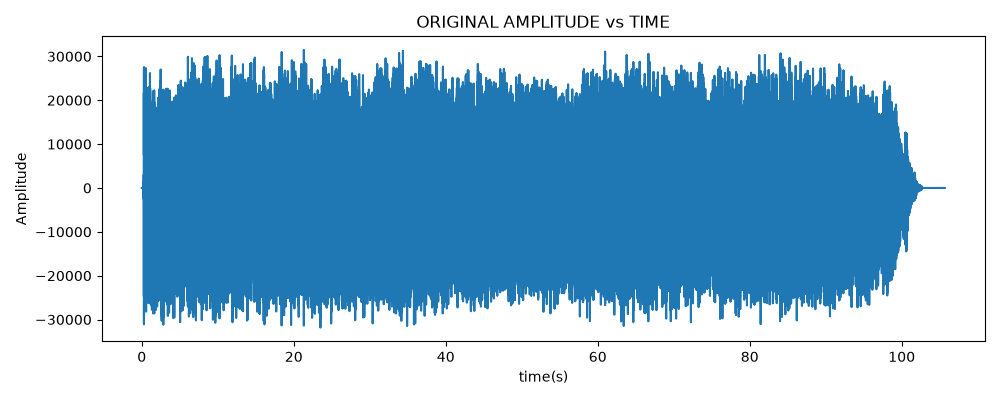

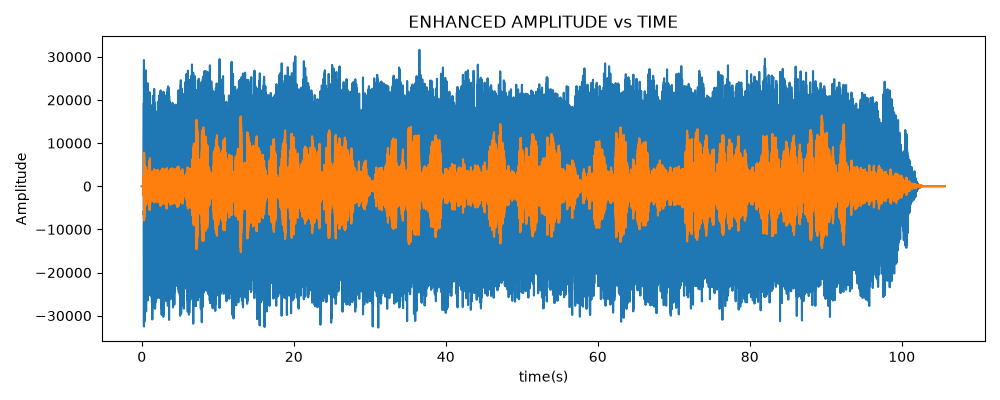

In [10]:
# Write output WAV file
enhanced_data = write_file(left, right, sample_rate, 'i_wanna_be_your_man_harmonicsPI.wav')

# Calculations for graph display
duration = len(data) / sample_rate
time = np.linspace(0.0, duration, num=len(data))

# Graph original vs final song
plot(time, data, 'ORIGINAL AMPLITUDE vs TIME', 'time(s)', 'Amplitude')
plot(time, enhanced_data, 'ENHANCED AMPLITUDE vs TIME', 'time(s)', 'Amplitude')

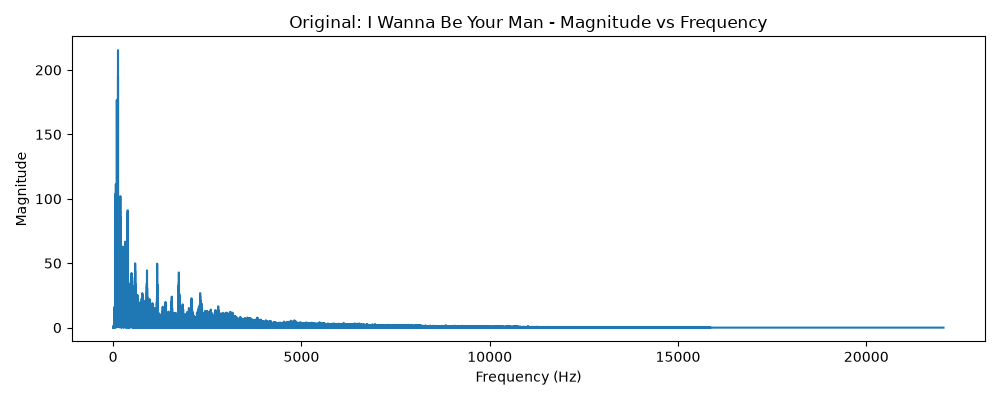

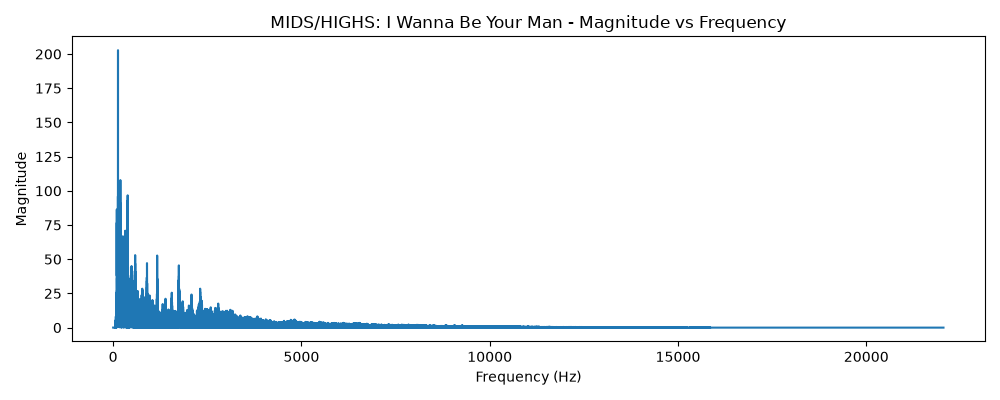

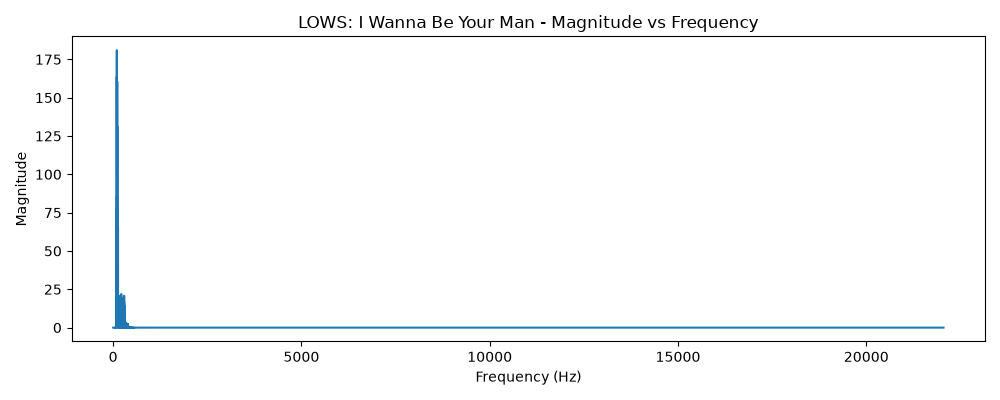

: 

In [ ]:
# Compare frequency graphs for original and enhanced song
original_amplitude = transform(data, sample_rate)
enhanced_left_amplitude = transform(enhanced_data[:, 0].astype(float), sample_rate)
enhanced_right_amplitude = transform(enhanced_data[:, 1].astype(float), sample_rate)

plot(f, original_amplitude, "Original: I Wanna Be Your Man - Magnitude vs Frequency", "Frequency (Hz)", "Magnitude")
plot(f, enhanced_left_amplitude, "MIDS/HIGHS: I Wanna Be Your Man - Magnitude vs Frequency", "Frequency (Hz)", "Magnitude")
plot(f, enhanced_right_amplitude, "LOWS: I Wanna Be Your Man - Magnitude vs Frequency", "Frequency (Hz)", "Magnitude")